# Multi-Agent Workflow with LangGraph Data Analysis Project

This project involves analyzing and visualizing data using Python, SQL, and LangChain. We will explore various datasets, perform data cleaning, and create insightful visualizations to understand the underlying patterns and trends within a multi-agent workflow framework.

# Introduction

In this project, We have meticulously gathered and analyzed a wealth of information, applying a range of skills and techniques to bring my vision to life. From the initial brainstorming sessions to the final touches, every step has been a learning experience, pushing the boundaries of my knowledge and capabilities.

## Workflow and Thought Process

### 1. Initial Brainstorming and Planning
The core objective of this project was to **develop a LangChain multi-agent workflow with a supervisor agent and make it work entirely using the selected tools and its own memory and reasoning capabilities**. To achieve this, I began with a series of brainstorming sessions to outline the project's scope, objectives, and key deliverables. This phase involved:
- Identifying the problem or opportunity.
- Defining the project's goals and success criteria.
- Researching existing solutions and technologies.

### 2. Research and Data Collection
Once the initial plan was in place, I moved on to gathering the necessary data and resources. This involved:
- Conducting literature reviews and market research.
- Collecting and organizing relevant datasets.
- Identifying key tools and technologies, including **LangChain, LangChain, Wikipedia tools, Python REPL tool, stock data analysis tool**.

### 3. Design and Prototyping
With a solid foundation of information, I proceeded to design and prototype the solution. This phase included:
- Creating wireframes and mockups to visualize the end product.
- Developing initial prototypes to test feasibility.
- Iterating on designs based on feedback and testing results.

### 4. Development and Implementation
The development phase was where the bulk of the work took place. Key activities included:
- Writing clean, efficient code using the selected technologies.
- Integrating various components to ensure seamless functionality.
- Conducting unit tests and debugging to maintain code quality.

### 5. Testing and Refinement
After the initial development, rigorous testing was conducted to ensure the solution met all requirements. This involved:
- Performing functional, performance, and security testing.
- Gathering user feedback and making necessary adjustments.
- Refining the solution to enhance usability and performance.
- Using different queries to see the agent respond to different inputs.

## Challenges and Learning Experiences
Throughout the development process, I encountered numerous challenges and obstacles. However, these hurdles only served to strengthen my problem-solving skills and deepen my understanding of the subject matter. By overcoming these difficulties, I was able to refine my approach and deliver a product that I am truly proud of.

## Conclusion
I invite you to explore the details of this project, where you will find comprehensive explanations of the methodologies used, the data analyzed, and the results achieved. I hope that my work not only meets your expectations but also inspires you to embark on your own creative endeavors.

To ensure our environment is properly set up for the upcoming project, we execute the following installation commands. These commands will install all necessary packages and dependencies required for the tasks ahead. 

In [15]:
!pip install --quiet wikipedia==1.4.0 
!pip install langchain-core==0.3.59 
!pip install langgraph==0.4.3 
!pip install langchain-openai==0.3.16 
!pip install langchain-experimental==0.3.4 
!pip install langgraph-supervisor==0.0.21


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
  Using cached langchain_core-0.3.59-py3-none-any.whl.metadata (5.9 kB)
Using cached langchain_core-0.3.59-py3-none-any.whl (437 kB)
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.67
    Uninstalling langchain-core-0.3.67:
      Successfully uninstalled langchain-core-0.3.67
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.26 requires langchain-core<1.0.0,>=0.3.66, but you have langchain-core 0.3.59 which is incompatible.
langchain-community 0.3.26 requires langchain-core<1.0.0,>=0.3.66, but you have langchain-core 0.3.59 which is incompatible.
crewai 0.30.11 requires langchain<0.2.0,>=0.1.10, but you have 

### Tool 1: Wikipedia Search

We'll utilize the `wikipedia` Python library to conduct Wikipedia searches and retrieve informative summaries about various companies. This tool interacts with Wikipedia's API in the background, which does not require an API key.

This library provides two functions that we'll use to search for and summarize company information:

1. `wikipedia.search()`: Searches Wikipedia and returns the highest-ranking page titles.
2. `wikipedia.summary()`: Retrieves a summary from a specified page. The `sentences` argument can be used to control the length of the summary (number of sentences) returned.

In [16]:
from typing import Annotated
import wikipedia
from langchain_core.tools import tool

@tool
def wikipedia_tool(
    query: Annotated[str, "The Wikipedia search to execute to find key summary information."],
):
    """Use this to search Wikipedia for factual information."""
    try:
        # Step 1: Search using query
        results = wikipedia.search(query)
        
        if not results:
            return "No results found on Wikipedia."
        
        # Step 2: Retrieve page title
        title = results[0]

        # Step 3: Fetch summary
        summary = wikipedia.summary(title, sentences=8, auto_suggest=False, redirect=True)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\nWikipedia summary: {summary}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

To evaluate the functionality of the `wikipedia_tool`, we can perform a test by executing a search query. This will help us understand how the tool interacts with the Wikipedia API and retrieves summary information. Below is an example of how to test the tool with a sample query:

```python
# Example test for the wikipedia_tool
test_query = "Python (programming language)"
result = wikipedia_tool(test_query)
print(result)
```

In this test:
1. We define a `test_query` with the search term "Python (programming language)".
2. We call the `wikipedia_tool` function with this query.
3. We print the result to see the summary information retrieved from Wikipedia.

By running this test, we can verify if the tool correctly searches Wikipedia, handles potential errors, and returns the expected summary.

In [17]:
# Test with Apple query
company_name = "Apple Inc."
wiki_summary = wikipedia_tool.invoke(f"{company_name}")
print(wiki_summary)

Successfully executed:
Wikipedia summary: Apple Inc. is an American multinational corporation and technology company headquartered in Cupertino, California, in Silicon Valley. It is best known for its consumer electronics, software, and services. Founded in 1976 as Apple Computer Company by Steve Jobs, Steve Wozniak and Ronald Wayne, the company was incorporated by Jobs and Wozniak as Apple Computer, Inc. the following year. It was renamed Apple Inc. in 2007 as the company had expanded its focus from computers to consumer electronics. Apple is the largest technology company by revenue, with US$391.04 billion in the 2024 fiscal year.

If you have completed all tasks, respond with FINAL ANSWER.


### Tool 2: Stock Performance Data

In this section, we will develop a comprehensive tool designed to load stock performance data from a local CSV file, filter the data based on the user's query, and return the relevant results. This tool will utilize stock *ticker symbols*, which are unique identifiers assigned to publicly traded companies, to fetch and display pertinent information for a specified company.

The process involves the following detailed steps:

1. **Loading Data**: 
   - We will begin by reading stock performance data from a CSV file stored locally. This file contains historical stock prices and other relevant metrics for various companies.
   - The CSV file should be structured with columns that include, but are not limited to, the date, open price, high price, low price, close price, adjusted close price, and trading volume.

2. **Filtering Data**: 
   - Once the data is loaded, we will filter it according to the user's query. The query will typically include the stock ticker symbol of the company of interest.
   - We will implement a mechanism to extract and return only the data corresponding to this ticker symbol. This involves searching through the dataset and isolating rows that match the specified ticker symbol.

3. **Returning Results**: 
   - After filtering the data, we will format the results and present them to the user. This may include displaying historical stock prices, trading volumes, and other relevant performance metrics.
   - We will ensure that the output is user-friendly and easy to interpret, possibly by summarizing key statistics or visualizing the data through charts or graphs.

Here are the companies and their corresponding ticker symbols for which stock data is available in our environment, loaded in CSV files:

- Apple Inc. (AAPL)
- Microsoft Corporation (MSFT)
- Amazon.com, Inc. (AMZN)
- Google LLC (GOOGL)
- Facebook, Inc. (FB)


In [18]:
import pandas as pd
import os

@tool
def stock_data_tool(
    company_ticker: Annotated[str, "The ticker symbol of the company to retrieve their stock performance data."], 
    num_days: Annotated[int, "The number of days of stock data required to respond to the user query."]
) -> str:
    """
    Use this to look-up stock performance data for companies to retrieve a table from a CSV. You may need to convert company names into ticker symbols to call this function, e.g, Apple Inc. -> AAPL, and you may need to convert weeks, months, and years, into days.
    """
    
    # Load the CSV for the company requested
    file_path = f"data/{company_ticker}.csv"

    if os.path.exists(file_path) is False:
        return f"Sorry, but data for company {company_ticker} is not available. Please try Apple, Amazon, Meta, Microsoft, Netflix, or Tesla."
    
    stock_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)

    # Ensure the index is in date format
    stock_df.index = stock_df.index.date
    
    # Maximum num_days supported by the dataset
    max_num_days = (stock_df.index.max() - stock_df.index.min()).days
    
    if num_days > max_num_days:
        return "Sorry, but this time period exceeds the data available. Please reduce it to continue."
    
    # Get the most recent date in the DataFrame
    final_date = stock_df.index.max()

    # Filter the DataFrame to get the last num_days of stock data
    filtered_df = stock_df[stock_df.index > (final_date - pd.Timedelta(days=num_days))]

    return f"Successfully executed the stock performance data retrieval tool to retrieve the last *{num_days} days* of data for company **{company_ticker}**:\n\n{filtered_df.to_markdown()}\n\nIf you have completed all tasks, respond with FINAL ANSWER."

In [19]:
retrieved_data = stock_data_tool.invoke({"company_ticker": "META", "num_days": 4})
print(retrieved_data)

Successfully executed the stock performance data retrieval tool to retrieve the last *4 days* of data for company **META**:

|            | Close/Last   |   Volume | Open    | High    | Low       |
|:-----------|:-------------|---------:|:--------|:--------|:----------|
| 2025-05-28 | $643.58      |  9042874 | $642.60 | $650.88 | $642.5472 |
| 2025-05-27 | $642.32      |  9508367 | $635.41 | $643.08 | $632.75   |

If you have completed all tasks, respond with FINAL ANSWER.


In [20]:
retrieved_data = stock_data_tool.invoke({"company_ticker": "AMZN", "num_days": 4})
print(retrieved_data)

Successfully executed the stock performance data retrieval tool to retrieve the last *4 days* of data for company **AMZN**:

|            | Close/Last   |   Volume | Open     | High    | Low     |
|:-----------|:-------------|---------:|:---------|:--------|:--------|
| 2025-05-28 | $204.72      | 28549750 | $205.915 | $207.66 | $204.41 |
| 2025-05-27 | $206.02      | 34892040 | $203.085 | $206.69 | $202.19 |

If you have completed all tasks, respond with FINAL ANSWER.


Because we do not have data about Google company, so far the Agent can not see and print any info about this company. Let´s see:

In [21]:
retrieved_data = stock_data_tool.invoke({"company_ticker": "Google", "num_days": 4})
print(retrieved_data)

Sorry, but data for company Google is not available. Please try Apple, Amazon, Meta, Microsoft, Netflix, or Tesla.


### Tool 3: Generating and Running Python Code

The third and final tool you'll need is designed to run Python code to create visualizations based on the stock data retrieved by the Stock Performance tool.

This tool leverages the `PythonREPL` class, which is part of LangChain's experimental library, `langchain_experimental`. The `PythonREPL` class reads Python code provided as a string, executes it, and returns the results.

In our agents, the LLM will identify when this tool is necessary for visualization, generate the appropriate code to create the visualization, and then call the tool with the generated code as input.

In [22]:
from langchain_experimental.utilities import PythonREPL

repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user. The chart should be displayed using `plt.show()`."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed the Python REPL tool.\n\nPython code executed:\n\`\`\`python\n{code}\n\`\`\`\n\nCode output:\n\`\`\`\n{result}\`\`\`"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
)

### Tool Name and Description

We can use the `.name` and `.description` attributes from the `tool` decorator to access both the name and description information about each tool we created. The descriptions are the ones we provided within the triple quotes (`""" """`) in the tool function.

In [23]:
# Loop through the tools and extract the .name and .description attributes
for tool in [wikipedia_tool, stock_data_tool, python_repl_tool]:
    print(f"The description for {tool.name}:\n> {tool.description}\n")

The description for wikipedia_tool:
> Use this to search Wikipedia for factual information.

The description for stock_data_tool:
> Use this to look-up stock performance data for companies to retrieve a table from a CSV. You may need to convert company names into ticker symbols to call this function, e.g, Apple Inc. -> AAPL, and you may need to convert weeks, months, and years, into days.

The description for python_repl_tool:
> Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user. The chart should be displayed using `plt.show()`.



### Modifying the Worker Agent Prompts

To ensure that the worker agents interact effectively with the supervisor agent, we need to provide them with clear and detailed instructions. These instructions should guide the worker agents on how to communicate, report progress, and handle any issues that may arise during their tasks. Here are some key points to include in the modified prompts:

1. **Introduction and Purpose**:
   - Briefly explain the role of the worker agent and its importance in the overall system.
   - Highlight the collaborative nature of the task and the need for effective communication with the supervisor agent.

2. **Communication Protocol**:
   - Specify the format and frequency of status updates to the supervisor agent.
   - Provide guidelines on how to ask for clarifications or additional information if needed.
   - Emphasize the importance of clear and concise communication.

3. **Task Execution**:
   - Outline the steps the worker agent should follow to complete its assigned tasks.
   - Include any specific instructions or best practices that should be adhered to.
   - Mention any tools or resources that the worker agent should utilize.

4. **Error Handling and Reporting**:
   - Describe the procedure for reporting errors or issues encountered during task execution.
   - Encourage the worker agent to suggest potential solutions or workarounds when reporting problems.
   - Stress the importance of timely and accurate error reporting to minimize disruptions.

5. **Completion and Handover**:
   - Define the criteria for task completion and the process for handing over the results to the supervisor agent.
   - Include instructions on how to document the work done and any relevant findings or observations.
   - Remind the worker agent to confirm with the supervisor agent that the task has been completed satisfactorily.

By incorporating these detailed instructions into the worker agent prompts, we can enhance the efficiency and effectiveness of the collaboration between worker agents and the supervisor agent.

In [24]:
import os
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

llm = ChatOpenAI(model="gpt-4o-mini")

# Research agent
research_agent = create_react_agent(
    llm,
    tools=[wikipedia_tool, stock_data_tool],
    prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, including looking-up factual information and stock data. DO NOT write any code.\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="researcher"
)

# Analyst agent
analyst_agent = create_react_agent(
    llm,
    [python_repl_tool],
    prompt=(
        "You are an agent that can run arbitrary Python code.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with tasks that require running code to produce an output.\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="analyst"
)

### Establishing the Supervisor Agent

With the `"researcher"` and `"analyst"` agents now set up, the next step is to define the supervisor agent.

LangGraph offers the `langgraph-supervisor` library, which provides a range of abstractions designed to simplify the creation of multi-agent supervisory systems. This library will be our tool of choice for this task.

However, if you prefer to work with the more fundamental, core LangGraph code, you can refer to [**this detailed guide**](https://www.datacamp.com/workspace/external-link?url=https%3A%2F%2Flangchain-ai.github.io%2Flanggraph%2Ftutorials%2Fmulti_agent%2Fagent_supervisor%2F%233-create-supervisor-from-scratch) in the LangGraph documentation.

The `create_supervisor()` function from `langgraph-supervisor` is similar to the `create_react_agent()` function found in `langgraph.prebuilt`. It offers a pre-configured class that requires only the agents to be managed, a language model (LLM) for generating the necessary supervisory text and user responses, and a `prompt` to guide its operations. This class comes with built-in features such as a conversation history mechanism, a function to determine when to delegate tasks, and more.

While `create_supervisor()` supports numerous parameters to customize its default behavior, we will focus on two key parameters:

1. `add_handoff_back_messages`: This parameter allows for additional messages to be included when a worker agent returns the task to the supervisor.
2. `output_mode`: This parameter dictates how messages from worker agents are incorporated into the system's conversation history.

In [25]:
from langgraph_supervisor import create_supervisor

supervisor = create_supervisor(
    model=llm,
    agents=[research_agent, analyst_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research and data collection tasks to this agent\n"
        "- an analyst agent. Assign the creation of visualizations via code to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

![image-2](image-2.png)

### Visualizing the Supervisor

To ensure that the supervisor and its interactions with the agents are correctly set up, let's run the visualization code one final time. This will generate an updated graph that reflects the current state of the supervisor, including any tasks assigned to the research and analyst agents. By visualizing the supervisor, we can verify that the workflow is functioning as intended and make any necessary adjustments.

Run the following code to generate the updated visualization:

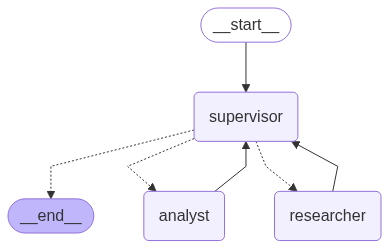

In [26]:
# Visualize your graph
supervisor

### Testing User Inputs with Different Queries

Now it's time to put our supervisor agent to the test by querying it with various questions. This section will help us evaluate how well the supervisor manages the tasks assigned to the research and analyst agents. By testing different queries, we can observe the interactions and results produced by the agents, ensuring that the workflow is functioning as expected.

Here are some example queries to test:

- Who is Apple's CEO?
- Has Tesla's share price increased over the last month?

Run these queries through the supervisor to see how it delegates tasks to the research and analyst agents and to review the results they produce.

In [27]:
from course_helper_functions import pretty_print_messages

for chunk in supervisor.stream(
    {"messages": [{"role": "user", "content": "Who is Apple's CEO?"}]}
):
    pretty_print_messages(chunk)

Update from node supervisor:


================================ Human Message =================================

Who is Apple's CEO?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_researcher (call_YYiy3RsWMV95eXp6kee69YDs)
 Call ID: call_YYiy3RsWMV95eXp6kee69YDs
  Args:
================================= Tool Message =================================
Name: transfer_to_researcher

Successfully transferred to researcher


Update from node researcher:


================================ Human Message =================================

Who is Apple's CEO?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_researcher (call_YYiy3RsWMV95eXp6kee69YDs)
 Call ID: call_YYiy3RsWMV95eXp6kee69YDs
  Args:
================================= Tool Message =================================
Name: transfer_to_researcher

Successfully transferred to researcher
==

![image-4](image-4.png)

Update from node supervisor:


================================ Human Message =================================

Has Tesla's share price increased over the last month? Show a line plot with the evolution and the data you may find.
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_researcher (call_IDJrow2vDbsmNzD9EU9XDkt2)
 Call ID: call_IDJrow2vDbsmNzD9EU9XDkt2
  Args:
================================= Tool Message =================================
Name: transfer_to_researcher

Successfully transferred to researcher


Update from node researcher:


================================ Human Message =================================

Has Tesla's share price increased over the last month? Show a line plot with the evolution and the data you may find.
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_researcher (call_IDJrow2vDbsmNzD9EU9XDkt2)
 Cal

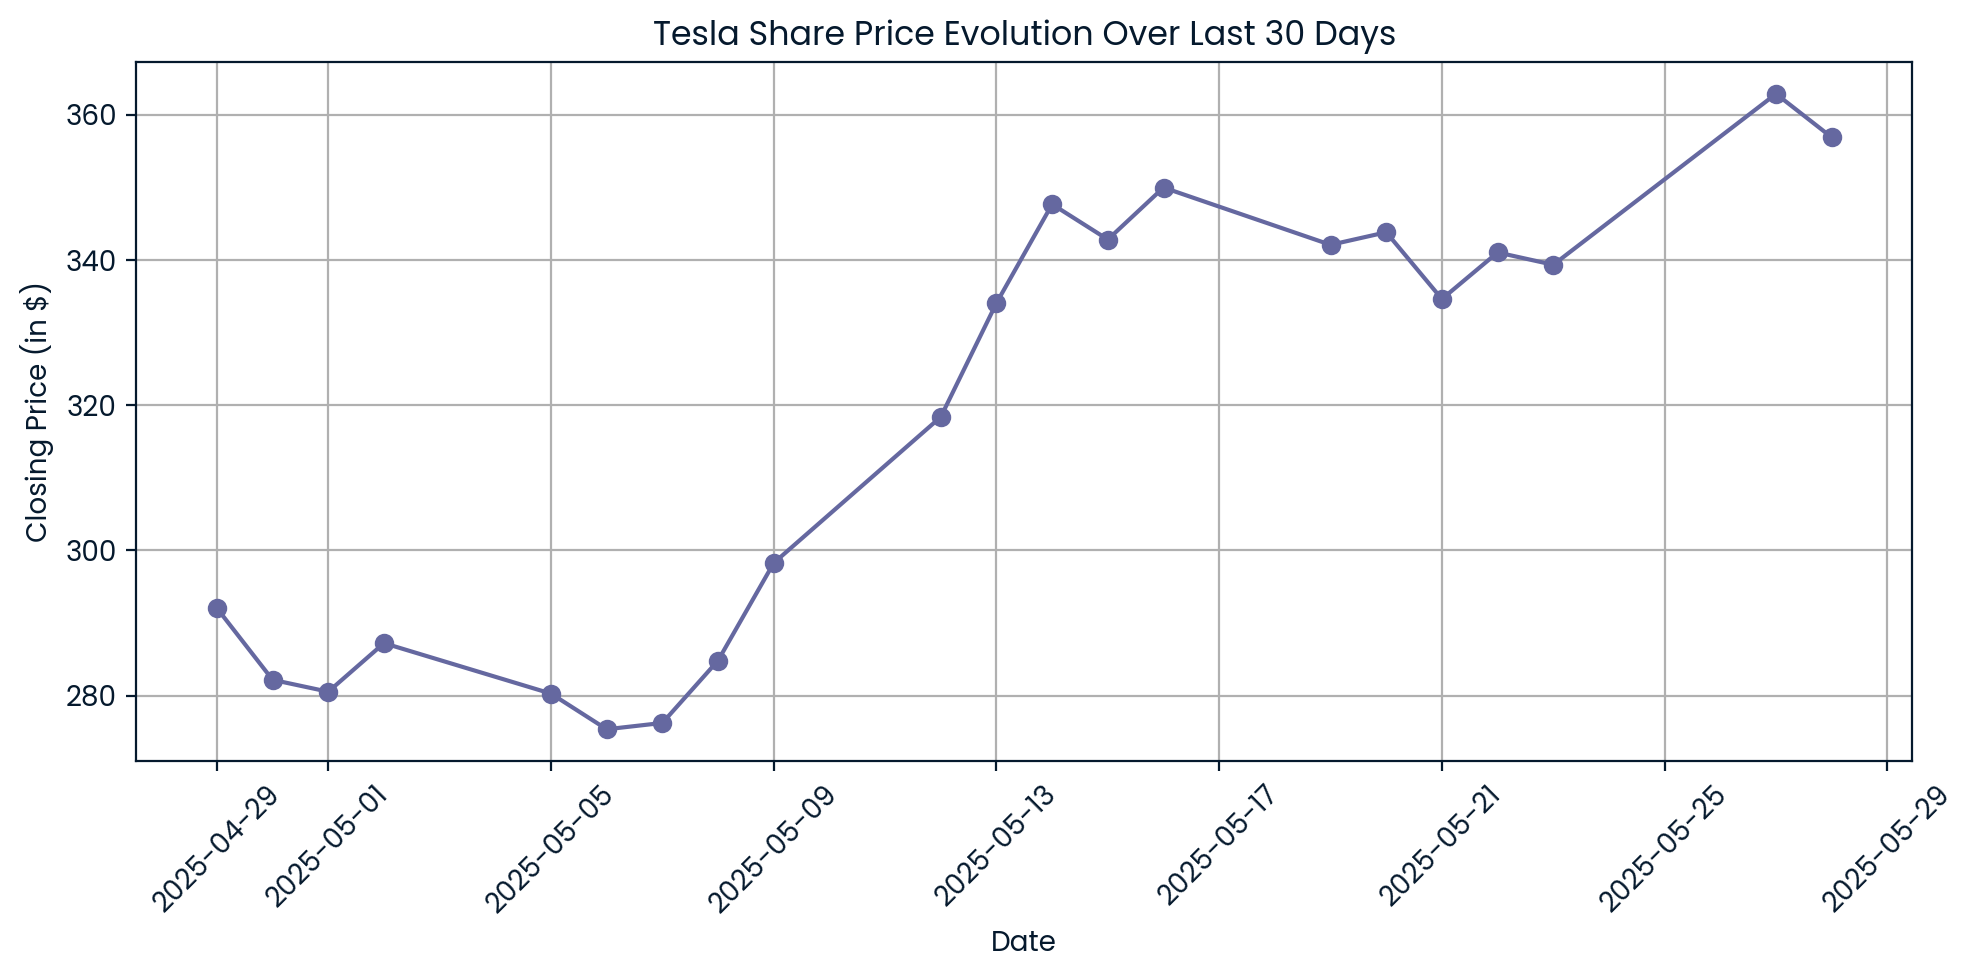

Update from node analyst:


================================ Human Message =================================

Has Tesla's share price increased over the last month? Show a line plot with the evolution and the data you may find.
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_researcher (call_IDJrow2vDbsmNzD9EU9XDkt2)
 Call ID: call_IDJrow2vDbsmNzD9EU9XDkt2
  Args:
================================= Tool Message =================================
Name: transfer_to_researcher

Successfully transferred to researcher
================================== Ai Message ==================================
Name: researcher
Tool Calls:
  stock_data_tool (call_HcQMeSyKbffvLJn5zQbSA9nQ)
 Call ID: call_HcQMeSyKbffvLJn5zQbSA9nQ
  Args:
    company_ticker: TSLA
    num_days: 30
================================= Tool Message =================================
Name: stock_data_tool

Successfully executed the stock performance data retr

In [28]:
from course_helper_functions import pretty_print_messages

for chunk in supervisor.stream(
    {"messages": [{"role": "user", "content": "Has Tesla's share price increased over the last month? Show a line plot with the evolution and the data you may find."}]}
):
    pretty_print_messages(chunk)

## Conclusion

### Overview

In this project, we developed a multi-agent system to handle various user queries by delegating tasks to specialized agents. The primary components of our system included a supervisor agent, a research agent, and an analyst agent. The supervisor agent was responsible for receiving user queries and delegating tasks to the research and analyst agents, who then performed the necessary operations to gather and analyze data.

### Scope and Logic

1. **Supervisor Agent**: This agent acted as the central coordinator. It received user queries and determined which tasks needed to be performed by the research and analyst agents. The supervisor then aggregated the results and presented them to the user.

2. **Research Agent**: This agent was responsible for gathering information from various sources. For example, when asked about the CEO of Apple, the research agent would search for the most recent and accurate information available.

3. **Analyst Agent**: This agent took the data provided by the research agent and performed further analysis. For instance, when asked about Tesla's share price, the analyst agent would fetch historical stock data, analyze it, and generate visualizations to show the trend over the last month.

### Achievements

- **Task Delegation**: Successfully implemented a system where the supervisor agent could delegate tasks to specialized agents.
- **Data Gathering and Analysis**: Demonstrated the ability to gather and analyze data based on user queries.
- **Visualization**: Created visual representations of data to provide clear insights.

### Future Improvements

While the project has achieved its primary goals, there are several areas for future enhancement:

1. **Enhanced Data Sources**: Integrate more diverse and reliable data sources to improve the accuracy and comprehensiveness of the information gathered.
2. **Natural Language Processing (NLP)**: Improve the NLP capabilities of the supervisor agent to better understand and process more complex user queries.
3. **Scalability**: Optimize the system to handle a larger volume of queries simultaneously, ensuring efficient performance.
4. **User Interface**: Develop a more user-friendly interface to make the system accessible to a broader audience.
5. **Machine Learning**: Incorporate machine learning algorithms to predict trends and provide more insightful analysis.

### Final Thoughts

This project has laid a solid foundation for a multi-agent system capable of handling diverse user queries through task delegation and specialized processing. By continuing to enhance the system, we can create a more robust, efficient, and user-friendly tool that can serve a wide range of applications.

Thank you for following along with this project. We look forward to seeing how it evolves in the future.